# Beaver's dams detection from SAR

**OBJECTIVE**: In this notebook we will asses the performance Sentinel-1 and SAOCOM SAR data for the detection of beaver dams in southern Argentina.

Google Earth Engine (GEE) is used to extract the data (materialized composites and point sampling).
All modelling, tuning and interpretation happen here.

In [ ]:
# =====================================================================
# 0. SETUP
# =====================================================================

# We import all the libraries and tools that we are going to use in this project.
# We retrieve all the packages from the UCL's Centre for Advanced Spatial Analysis (CASA)'s Computer Environment.
# For more information, you can visit https://ucl-casa.github.io/sds/ # CHECK
# Also, We use the `esda` library for exploratory spatial data analysis and `libpysal` for spatial data science.
!pip install esda libpysal

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.spatial import cKDTree

# Methodology: We choose a Random Forest algorithm classifier (Breinman, 2001) to discriminate between beaver dam presence and absence. 
from sklearn.ensemble import RandomForestClassifier

# Pipeline and preprocessing
from sklearn.model_selection import train_test_split, GroupKFold

# Metrics and interpretation
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score,
                             cohen_kappa_score, roc_auc_score, average_precision_score)
from sklearn.inspection import permutation_importance


# Spatial Analysis
from libpysal.weights import DistanceBand, w_difference
from esda.moran import Moran


##########################
# Parmeters and Settings #
##########################

# We set the parameters that will be used throughout the notebook.

# We set a random seed for reproducibility of results. 
# This ensures that the random processes in the code (like data splitting) produce the same results each time the code is run.
SEED = 17
np.random.seed(SEED)

# We set the working directory.
os.chdir('/home/jovyan/work/Desktop/R/UCL/Dissertation/dissertation_scripts/')

# We set the buffer size in meters that was applied around every mapped dam when sampling negatives.
# This buffer is used to avoid sampling negative points too close to known dam locations, which could lead to biased model training and evaluation.
BUFFER_M = 30 


In [3]:
# =====================================================================
# 1. DATA PRESENTATION
# =====================================================================

# We set the path to our data file.
PATH_DATA = "data/rf_points_dataset.csv"

# We upload our data. It contains the our sample of points: the mapped beaver dams and the random points sampled in GEE.
pixels = pd.read_csv(PATH_DATA)

# We rename our variable class into "dam".
pixels = pixels.rename(columns={'class': 'dam'})

print("=== BEAVER DAMs DATASET ===")
print(f"Our dataset has {pixels.shape[0]:,} rows and {pixels.shape[1]} columns.")
print("Columns:", list(pixels.columns))

=== BEAVER DAMs DATASET ===
Our dataset has 142,443 rows and 13 columns.
Columns: ['dam', 'source', 'x', 'y', 's1_VV', 's1_VH', 's1_ratio', 'sao_HH', 'sao_HV', 'sao_ratio', 'npp', 'slope', 'elevation']


In [4]:
# Let's have a quick look to it
pixels.head()

,dam,source,x,y,s1_VV,s1_VH,s1_ratio,sao_HH,sao_HV,sao_ratio,npp,slope,elevation
0,1,inventory,623575.0,3.935245e+06,-11.360855,-16.683250,5.322395,-2.227821,-6.004091,3.776270,0.4426,3.961106,337.52700
1,1,inventory,601645.0,3.959025e+06,-13.544585,-21.773311,8.228726,-7.219330,-10.711860,3.492530,0.6832,20.893164,265.63593
2,1,inventory,662375.0,3.936565e+06,-11.171664,-19.768988,8.597324,-4.813170,-8.666070,3.852899,0.4655,4.004015,204.79870
3,1,inventory,661565.0,3.936955e+06,-14.540333,-23.730745,9.190413,-4.009239,-8.827114,4.817875,0.4365,3.048583,194.41250
4,1,inventory,658075.0,3.940315e+06,-11.350133,-20.170481,8.820347,-2.968746,-5.960636,2.991890,0.4536,3.991674,247.31944


Our dataset has 142,443 points. Each point contain information about 13 variables. The presence or absence of dams, the source of the information, the coordinates, the backscatter features of each satellite and three environmental variables (NPP, Slope, Elevation),

In [5]:
# Lets's see our missing values.
pixels.isna().sum().sort_values(ascending=False)

dam          0
source       0
x            0
y            0
s1_VV        0
s1_VH        0
s1_ratio     0
sao_HH       0
sao_HV       0
sao_ratio    0
npp          0
slope        0
elevation    0
dtype: int64

Our dataset has no missing values in any of its features.

In [6]:
# Now, let's have a look to our target variable, `dam`.
# If `dam` == 1, there is a beaver's dam
# If `dam` == 0, there is not a beaver's dam

print("\n=== CLASS BALANCE ===")
pixels['dam'].value_counts()


=== CLASS BALANCE ===


dam
0    114205
1     28238
Name: count, dtype: int64

The class distribution is imbalanced, with mapped dams representing the minority class in the real world.

28,238 mapped dam locations corresponding to beaver dams.
114,205 pseudo negatives randomly selected further than 30 meters from any mapped dam locations.

In [7]:
# We arrange data into a features matrix and target vector.
# SENTINEL-1
FEATURES_S1      = ['s1_VV', 's1_VH', 's1_ratio']
# SAOCOM
FEATURES_SAOCOM  = ['sao_HH', 'sao_HV', 'sao_ratio']
# Environmental context
FEATURES_CONTEXT = ['npp', 'slope', 'elevation']

# Combine into the full feature list
FEATURES = FEATURES_S1 + FEATURES_SAOCOM + FEATURES_CONTEXT

In [8]:
# We run a quick exploratory data analysis to understand the distribution of our features and their relationship with the target variable.
# Class balance
print("\nBy 'source':")
print(pixels.groupby(['dam', 'source']).size())
 
# Let's build a summary of our variables.
print("\n=== FEATURE RANGES (describe) ===")
print(pixels[FEATURES].describe(percentiles=[.05, .5, .95]).T.round(3))
 


By 'source':
dam  source   
0    random       114205
1    inventory     28238
dtype: int64

=== FEATURE RANGES (describe) ===
              count     mean      std     min      5%      50%      95%  \
s1_VV      142443.0  -11.234    2.736 -27.486 -15.512  -11.285   -6.893   
s1_VH      142443.0  -18.855    3.493 -45.242 -24.865  -18.637  -13.726   
s1_ratio   142443.0    7.621    2.626  -1.483   3.774    7.383   12.308   
sao_HH     142443.0   -4.586    1.603 -13.741  -7.291   -4.529   -2.147   
sao_HV     142443.0   -8.668    2.715 -38.513 -13.134   -8.189   -5.224   
sao_ratio  142443.0    4.082    1.838  -1.202   1.742    3.815    7.009   
npp        142443.0    0.472    0.129   0.043   0.305    0.431    0.712   
slope      142443.0    8.653    7.676   0.000   0.669    6.303   24.916   
elevation  142443.0  254.566  147.095  25.000  83.284  215.094  554.151   

                max  
s1_VV        13.119  
s1_VH         2.652  
s1_ratio     28.513  
sao_HH        8.517  
sao_HV      

## ADD SCATTERPLOT

Sentinel-1 and SAOCOM backscatter values are generally negative, while the derived polarization ratios are positive on average. Among the environmental variables, elevation shows the greatest absolute variability, ranging from 25 to 1,025 m, whereas NPP has a relatively narrow range. Slope is highly variable, including values from 0° to approximately 39°. Overall, the broad ranges and standard deviations suggest substantial environmental and SAR variability across the sampled locations.

In [9]:
# We calculate the linear distance from each pseudo-negative point to the nearest mapped dam location
dam_xy = pixels.loc[pixels['dam'] == 1, ['x', 'y']].values
tree = cKDTree(dam_xy)
# For a positive, the nearest neighbour is itself (dist 0). In that case, we take the 2nd nearest neighbour (k=2).
dist, _ = tree.query(pixels[['x', 'y']].values, k=2)
pixels['dist_to_dam'] = np.where(pixels['dam'] == 1, dist[:, 1], dist[:, 0])
 
# For a negative, the 1st neighbour is already a real dam.
neg_dist = pixels.loc[pixels['dam'] == 0, 'dist_to_dam']
print("\n=== Distance to mapped dams (pseudo-negatives) ===")
print(f"min={neg_dist.min():.1f}  p5={neg_dist.quantile(.05):.1f}  "
      f"p50={neg_dist.quantile(.5):.1f}  p95={neg_dist.quantile(.95):.1f}  "
      f"max={neg_dist.max():.1f}")
print(f"negatives closer than {BUFFER_M} m to a dam: {(neg_dist < BUFFER_M).sum()}  "
      f"(expected ~0 given the buffer)")

# We enforce an exact 30 m buffer from the mapped dams to drop the few negatives that the rasterized
# GEE buffer left between MIN_NEG_DIST and the pixel-grid edge.
before_filter = len(pixels)
pixels = pixels[~((pixels['dam'] == 0) & (pixels['dist_to_dam'] < 30))].reset_index(drop=True)
print(f"Negatives dropped by exact {30} m buffer: {before_filter - len(pixels)}")
 
# --- Modelling frame summary ---
print("\n=== NEW MODELLING FRAME ===")
print(f"Total: {len(pixels):,} | positives: {(pixels['dam'] == 1).sum():,} | "
      f"negatives: {(pixels['dam'] == 0).sum():,}")
print(f"Columns: {list(pixels.columns)}")


=== Distance to mapped dams (pseudo-negatives) ===
min=22.4  p5=58.3  p50=313.8  p95=1163.9  max=3669.9
negatives closer than 30 m to a dam: 259  (expected ~0 given the buffer)
Negatives dropped by exact 30 m buffer: 259

=== NEW MODELLING FRAME ===
Total: 142,184 | positives: 28,238 | negatives: 113,946
Columns: ['dam', 'source', 'x', 'y', 's1_VV', 's1_VH', 's1_ratio', 'sao_HH', 'sao_HV', 'sao_ratio', 'npp', 'slope', 'elevation', 'dist_to_dam']


259 pseudo-negatives were removed. The total negative class is now 113,946 points, making our full dataset 142,184 points.

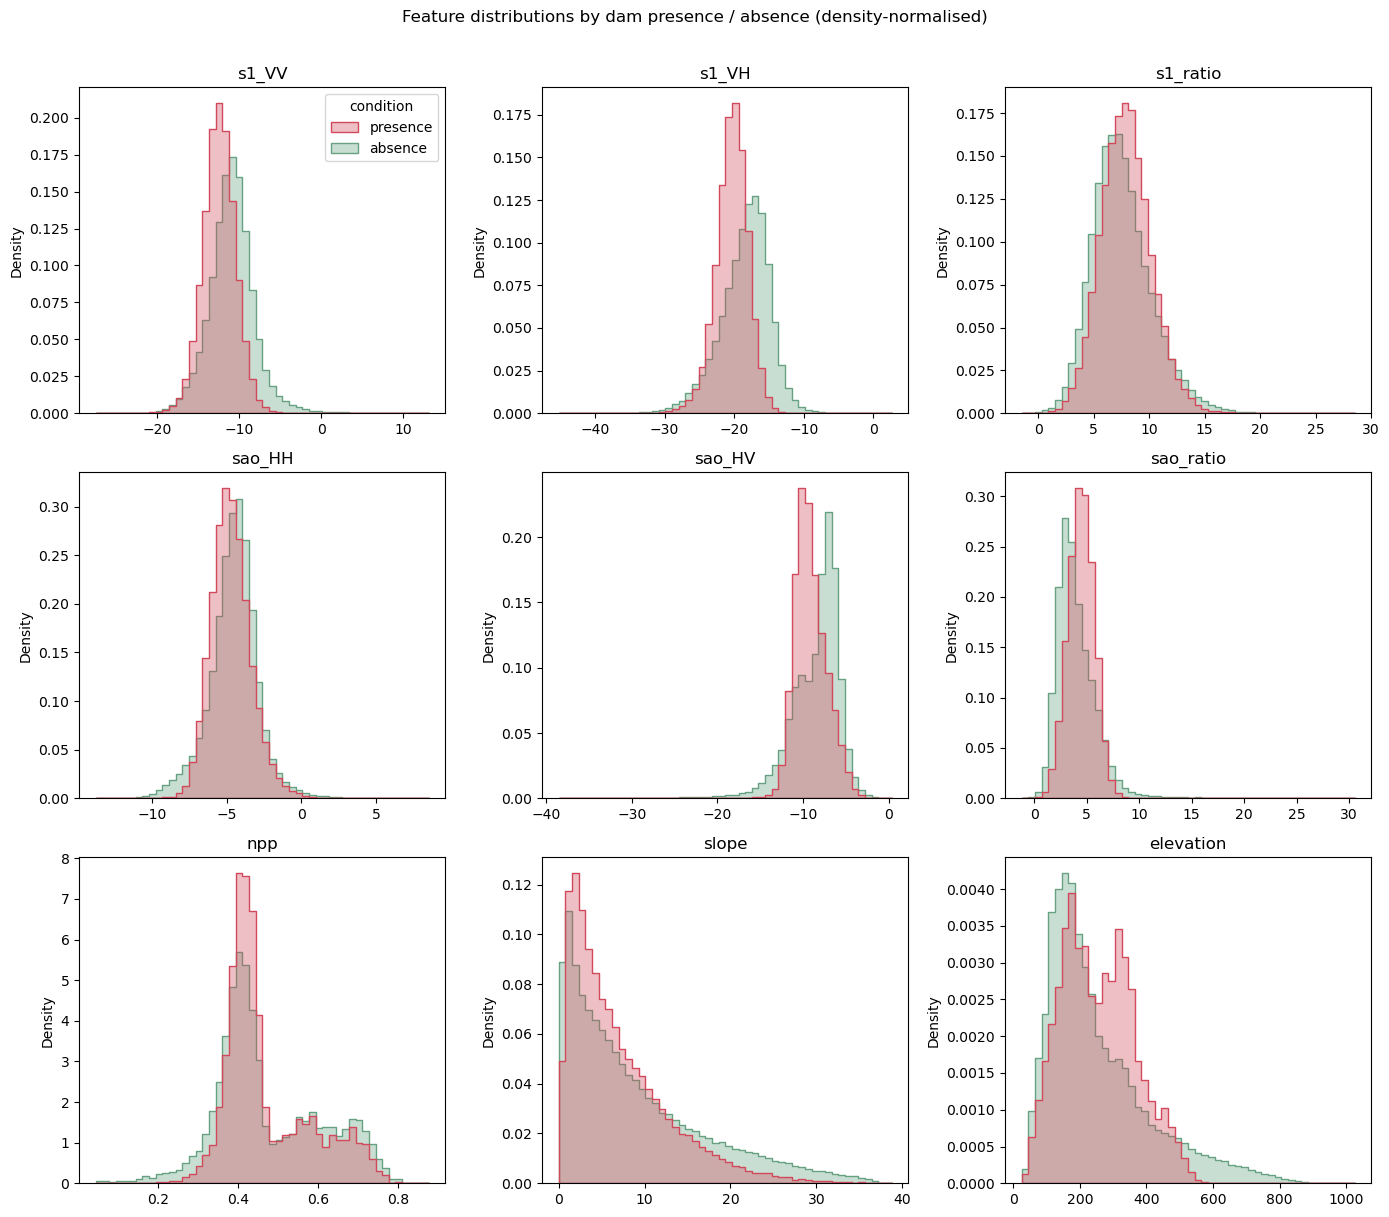

In [10]:
# Let's have a look to the distribution of our features by class (dam presence / absence).
# We set up the labels and color palette for the plots.
LABELS  = {1: 'presence', 0: 'absence'}
PALETTE = {'presence': '#d1495b', 'absence': '#66a182'}

# Temporary display column (text) just for plotting; the model still uses dam 1/0
plot_df = pixels.copy()
plot_df['condition'] = plot_df['dam'].map(LABELS)

ncols = 3
nrows = int(np.ceil(len(FEATURES) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    sns.histplot(data=plot_df, x=feat, hue='condition',
                 stat='density', common_norm=False,   # Normalise EACH group so as to have their shapes comparable
                 bins=50, element='step', fill=True, alpha=0.35,
                 palette=PALETTE, ax=axes[i], legend=(i == 0))
    axes[i].set_title(feat)
    axes[i].set_xlabel('')

for j in range(len(FEATURES), len(axes)):  
    axes[j].axis('off')

fig.suptitle('Feature distributions by dam presence / absence (density-normalised)', y=1.01)
fig.tight_layout()
plt.show()

The histograms by dam presence and absence, indicate that none of the individual variables provides a clear distinction between the two classes. This suggests that dam detection cannot be reliably based on a single variable or a fixed threshold. Instead, discrimination is likely to depend on the combined information provided by multiple predictors.

In respect to SAR variables, dam's pixels show lower average backscatter values than random pixels, consistent with the specular reflection expected over open water. However, it's worth mention than random pixels seems to reach even lower values than dam's pixels, particular in the SAOCOM images. This suggests that the random background sample also captured non-dam open-water bodies (e.g. lakes and rivers), meaning low backscatter is present in both classes and is therefore only a partial discriminator of dam presence. 

A visual inspection of the pseudo-absence pixels falling in the lowest decile of SAOCOM (HV) backscatter was carried out to test whether the random background sample had inadvertently captured non-dam open water. The inspection did not support this. Instead, these low-backscatter negatives reflected a mixture of phenomena that share low radar return, such as layover and shadow effects over steep mountain terrain, fast-flowing river channels (unsuitable for dam construction), urban surfaces, and dry grassland. This indicates that low backscatter alone does not discriminate beaver dams from the background, since several unrelated surface types produce similarly low returns; it therefore reinforces the need for a multivariate, multi-frequency approach rather than simple thresholding, and is consistent with the complementary contribution of the two SAR frequencies observed in the classification results.

Within the SAR variables, the greatest degree of separation is observed for the cross-polarised channels, particularly Sentinel-1 VH and SAOCOM HV. Locations associated with dam presence tend to exhibit higher backscatter values and less narrower distributions than dam-absence locations. In contrast, the VV and HH distributions show extensive overlap between classes and provide considerably less apparent univariate separation. The behaviour of the cross-polarised channels is physically plausible, given their sensitivity to volume-scattering effects that may arise from surfaces modified by beaver activity.

The environmental predictors show an apparently stronger separation between the two classes than most of the SAR variables. Dam-presence observations are particularly concentrated around NPP values of approximately 0.40–0.45 and are disproportionately represented within the approximately 250–400 m elevation range. However, these patterns should not be interpreted directly as evidence that NPP or elevation provides strong local discrimination of dam presence. Rather, they may reflect the relatively restricted environmental conditions in which beaver colonies occur across the broader study region. 

Finally, we compute a Spearman rank correlation matrix across numeric and binary variables. Spearman is preferred over Pearson because several variables are not normally distributed and is more robust to outliers. The aim is detecting potential redundancy.

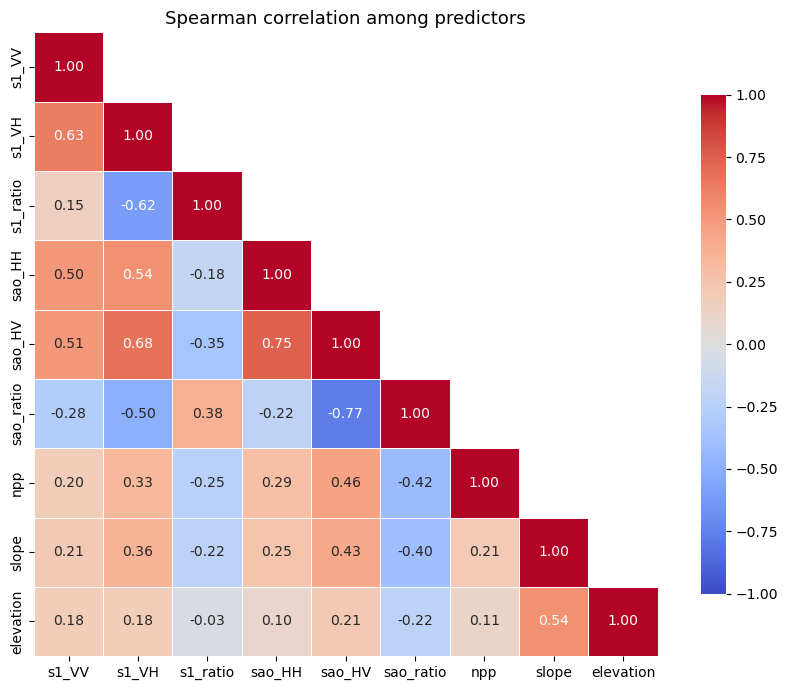

In [11]:
# # Spearman correlation matrix (redundancy check: S1 vs SAOCOM vs context)
corr = pixels[FEATURES].corr(method='spearman')

# Mask the upper triangle -> read it once, no mirror-image clutter
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

# Plot heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title("Spearman correlation among predictors", fontsize=13)
plt.tight_layout()
plt.show()


The Spearman correlation matrix for the nine predictors highlights some relevant patterns for comparing the two SAR sensors. 

Overall, the Sentinel-1 (C-band) and SAOCOM (L-band) variables show  moderate levels of association, with correlations such as VV–HH = 0.50 and VH–HV = 0.68, while several other cross-sensor relationships are weak or even negative. The absecense of a substantial redundancy indicates that the information provided by the two sensors may be complementary rather than overlapping.

The environmental variables (NPP, slope, and elevation) show generally weak correlations with the SAR variables, mostly within the range of 0.1–0.4, suggesting that they provide a distinct component of the information available to the models.


## Variable description

| Variable | Description | Type | Source | Spatial unit |
|---|---|---|---|---|
| `dam` | Presence (1) or absence (0) of beaver's dam | Binary (1/0) | Huertas Herrera et al (2020) inventory (presence) / random sampling (absence) | Pixel (10 m) |
| `s1_VV` | Sentinel-1 C-band co-polarised backscatter | Numeric (dB) | Sentinel-1 (ESA/Copernicus), 2025 | Pixel (10 m) |
| `s1_VH` | Sentinel-1 C-band cross-polarised backscatter | Numeric (dB) | Sentinel-1 (ESA/Copernicus), 2025 | Pixel (10 m) |
| `s1_ratio` | Sentinel-1 co-/cross-pol ratio (VV − VH) | Numeric (dB) | Derived from Sentinel-1 | Pixel (10 m) |
| `sao_HH` | SAOCOM L-band co-polarised backscatter | Numeric (dB) | SAOCOM (CONAE), 2025 | Pixel (10 m) |
| `sao_HV` | SAOCOM L-band cross-polarised backscatter | Numeric (dB) | SAOCOM (CONAE), 2025 | Pixel (10 m) |
| `sao_ratio` | SAOCOM co-/cross-pol ratio (HH − HV) | Numeric (dB) | Derived from SAOCOM | Pixel (10 m) |
| `npp` | Net primary productivity (annual) | Numeric (kgC/m²/yr) | MODIS MOD17A3HGF | Pixel (~463 m, resampled) |
| `slope` | Terrain slope | Numeric (degrees) | Copernicus GLO-30 DEM | Pixel (30 m, resampled) |
| `elevation` | Terrain elevation | Numeric (m a.s.l.) | Copernicus GLO-30 DEM | Pixel (30 m, resampled) |
| `x`, `y` | Projected coordinates (EPSG:32719) | Numeric (m) | — | Pixel (10 m) |
| `dist_to_dam` | Distance to the nearest known dam | Numeric (m) | Derived (cKDTree) | Pixel (10 m) |

*All predictors were sampled at 10 m in EPSG:32719. NPP, slope and elevation originate at coarser native resolutions and were resampled to the 10 m grid; their effective spatial support is therefore coarser than the SAR variables.*

In [12]:
# =====================================================================
# 2. MODELLING
# =====================================================================

# We define a reusable helper function used to summarize model performance  across the three models.
def summarize_performance(label, y_true, y_pred, y_proba):
    """Key classification metrics for BOTH classes.
    Accuracy is omitted due to the deliberate class balance in training."""
    return {
        'model':         label,
        'recall_dam':    recall_score(y_true, y_pred, pos_label=1),
        'recall_bg':     recall_score(y_true, y_pred, pos_label=0),
        'precision_dam': precision_score(y_true, y_pred, pos_label=1),
        'f1_dam':        f1_score(y_true, y_pred, pos_label=1),
        'kappa':         cohen_kappa_score(y_true, y_pred),
        'roc_auc':       roc_auc_score(y_true, y_proba),
        'pr_auc':        average_precision_score(y_true, y_proba),
    }

## Model training and evaluation
# First, we run a model with a random stratified 70/30 split that will be used as a baseline for comparison with the spatially blocked cross-validation.
def run_rf(features, label, test_size=0.3, verbose=True):
    X = pixels[features].values
    y = pixels['dam'].values
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, 
        test_size=test_size,
        stratify=y,
        random_state=SEED
        )

    if verbose:
        print(f"\n--- {label}: split ---")
        print(f"Train: {X_tr.shape[0]:,} samples x {X_tr.shape[1]} features")
        print(f"Test:  {X_te.shape[0]:,} samples x {X_te.shape[1]} features")
        print(f"Positive proportion -- train: {y_tr.mean():.1%} | test: {y_te.mean():.1%}")

    rf = RandomForestClassifier(
        n_estimators=500, 
        class_weight='balanced',
        random_state=SEED,
         n_jobs=-1)
    rf.fit(X_tr, y_tr)

    # Predict on BOTH sets to quantify overfitting (train - test gap)
    m_train = summarize_performance(label, y_tr,
                rf.predict(X_tr), rf.predict_proba(X_tr)[:, 1])
    m_test  = summarize_performance(label, y_te,
                rf.predict(X_te), rf.predict_proba(X_te)[:, 1])

    if verbose:
        gap = pd.DataFrame({
            'train': m_train, 'test': m_test,
            'train-test': {k: (m_train[k] - m_test[k]) if isinstance(m_train[k], (int, float)) else ''
                           for k in m_train}
        })
        gap = gap.drop(index='model')          # drop the label row from the numeric table
        print(f"\n{label} -- train vs test:")
        print(gap.round(3).to_string())
        print("\nTest classification report:")
        print(classification_report(y_te, rf.predict(X_te), digits=3))

    return rf, m_test, (y_te, rf.predict(X_te))   # test metrics feed the comparison table (2.4)

# ---- 2.3 Random Split: Sentinel-1 vs SAOCOM vs Combined Model ) ----
results = []
rf_s1,   m_s1,   pred_s1   = run_rf(FEATURES_S1,                   "Sentinel-1 only")
rf_sao,  m_sao,  pred_sao  = run_rf(FEATURES_SAOCOM,               "SAOCOM only")
rf_both, m_both, pred_both = run_rf(FEATURES_S1 + FEATURES_SAOCOM, "S1 + SAOCOM")
results.extend([m_s1, m_sao, m_both])

# ---- 2.4 Comparison table ----
results_df = pd.DataFrame(results).round(3)
print("\n=== MODEL COMPARISON (random 70/30 split) ===")
print(results_df.to_string(index=False))


--- Sentinel-1 only: split ---
Train: 99,528 samples x 3 features
Test:  42,656 samples x 3 features
Positive proportion -- train: 19.9% | test: 19.9%

Sentinel-1 only -- train vs test:
              train      test train-test
recall_dam      1.0  0.189566   0.810434
recall_bg       1.0  0.917125   0.082875
precision_dam   1.0  0.361793   0.638207
f1_dam          1.0   0.24878    0.75122
kappa           1.0  0.129957   0.870043
roc_auc         1.0  0.697463   0.302537
pr_auc          1.0  0.318035   0.681965

Test classification report:
              precision    recall  f1-score   support

           0      0.820     0.917     0.866     34184
           1      0.362     0.190     0.249      8472

    accuracy                          0.773     42656
   macro avg      0.591     0.553     0.557     42656
weighted avg      0.729     0.773     0.743     42656


--- SAOCOM only: split ---
Train: 99,528 samples x 3 features
Test:  42,656 samples x 3 features
Positive proportion -- train: 1

Under a stratified 70/30 random split, the combined Sentinel-1 + SAOCOM model consistently outperformed either sensor used individually across all major performance metrics. ROC-AUC increased from 0.697 for Sentinel-1 and 0.669 for SAOCOM to 0.805 for the combined model, while PR-AUC increased from 0.318 and 0.305 to 0.464, respectively. The same ranking was observed for Cohen’s kappa (0.130, 0.107, and 0.256). The consistency of this pattern across complementary performance metrics suggests that the advantage of the combined model is not driven by a single evaluation criterion.

When considered individually, Sentinel-1 and SAOCOM showed broadly comparable discriminatory performance, with Sentinel-1 performing marginally better across the main metrics. The difference between the two single-sensor models, however, was relatively modest and does not provide strong evidence that one sensor is intrinsically superior to the other. Rather, the more important result is the substantial improvement obtained when both sensors were combined. This improvement is consistent with the hypothesis that C-band Sentinel-1 and L-band SAOCOM capture partially complementary information relevant to beaver-dam detection, rather than being fully redundant sources of information. However, this interpretation should be treated as a preliminary hypothesis at this stage;

At the default probability threshold of 0.5, all three models showed relatively low recall for the dam class, with values of 0.190 for Sentinel-1, 0.166 for SAOCOM, and 0.263 for the combined model. This indicates that the default threshold is relatively conservative with respect to dam detection. Importantly, the combined model improved both dam-class recall and precision simultaneously: recall increased to 0.263 compared with 0.190 and 0.166 for the single-sensor models, while precision increased to 0.538 compared with 0.362 and 0.341. The simultaneous improvement in both dimensions is notable because it indicates that the gain from combining the sensors is not simply the result of moving to a different point along the precision–recall trade-off, but reflects improved class discrimination at the same operating threshold. An operational threshold will subsequently be selected using the True Skill Statistic, allowing performance to be assessed at a threshold chosen according to the intended classification objective rather than assumed a priori.

All three Random Forest models achieved perfect performance on the training data, whereas performance on the held-out test data was substantially lower. This highlights that training-set performance provides little information about the model's ability to generalise to unseen observations. More importantly, the random split does not account for the strong spatial structure of the positive class. Spatially close observations may therefore occur in both training and test sets, allowing the model to benefit from spatially autocorrelated information and potentially producing optimistic estimates of generalisation performance.

In [13]:
# We run a Moran's I correlogram to measure the spatial autocorrelation of the SAR features.
# This analysis helps us determine the appropriate block size for spatial cross-validation, ensuring that our model evaluation accounts for spatial dependencies in the data.

# We take a random subsample of 5000 pixels.
SUB_N = 5000
sub = pixels.sample(n=SUB_N, random_state=SEED).reset_index(drop=True)
coords = sub[['x', 'y']].values
sar_feats = FEATURES_S1 + FEATURES_SAOCOM        # We take only SAR features (the environmental context has regional autocorrelation, so it is excluded)
edges = [0, 250, 500, 750, 1000, 1500, 2000, 2500, 3000, 4000, 5000]  # We choose a ring boundaries approach. Each band measures autocorrelation only within a distance ring, excluding nearer neighbours.

print(f"Moran's I ring-based correlogram (n={SUB_N})")
print("each row expresses autocorrelation WITHIN that distance ring \n")
header = "ring (m)      | " + " ".join(f"{f.split('_',1)[1]:>7}" for f in sar_feats) + " |  mean"
print(header); print("-" * len(header))

# We run a loop over the specified distance bands to calculate Moran's I for each SAR feature.
# A positive Moran's I indicates that similar values cluster together, while a negative value suggests that dissimilar values are neighbors.
# The significance of the autocorrelation is assessed using permutation tests.
for i in range(1, len(edges)):
    d_lo, d_hi = edges[i-1], edges[i]
    # ring = neighbours within d_hi MINUS neighbours within d_lo
    w_hi = DistanceBand(coords, threshold=d_hi, binary=True, silence_warnings=True)
    w_ring = w_hi if d_lo == 0 else w_difference(
        w_hi, DistanceBand(coords, threshold=d_lo, binary=True, silence_warnings=True),
        constrained=False, silence_warnings=True)
    w_ring.transform = 'r'

    Is, cells = [], []
    for f in sar_feats:
        try:
            mi = Moran(sub[f].values, w_ring, permutations=99)    # How similar are the neighbors?
            mark = "" if mi.p_sim < 0.05 else "*"                # * = no significant autocorrelation at that band
            cells.append(f"{mi.I:+.2f}{mark:>1}"); Is.append(mi.I)
        except Exception:
            cells.append("   n/a")
    mean_I = np.mean(Is) if Is else float('nan')
    print(f"{d_lo:>4}-{d_hi:<5}   | " + " ".join(f"{c:>7}" for c in cells) + f" | {mean_I:+.2f}")

print("\n(* = p >= 0.05, not significant in that ring)")

Moran's I ring-based correlogram (n=5000)
each row expresses autocorrelation WITHIN that distance ring 

ring (m)      |      VV      VH   ratio      HH      HV   ratio |  mean
-----------------------------------------------------------------------
   0-250     |  +0.44   +0.45   +0.21   +0.54   +0.67   +0.55  | +0.48
 250-500     |  +0.28   +0.33   +0.17   +0.30   +0.45   +0.38  | +0.32
 500-750     |  +0.19   +0.22   +0.12   +0.20   +0.30   +0.26  | +0.21
 750-1000    |  +0.14   +0.17   +0.08   +0.11   +0.30   +0.29  | +0.18
1000-1500    |  +0.11   +0.14   +0.06   +0.10   +0.25   +0.22  | +0.15
1500-2000    |  +0.07   +0.11   +0.05   +0.07   +0.19   +0.17  | +0.11
2000-2500    |  +0.07   +0.09   +0.05   +0.06   +0.17   +0.15  | +0.10
2500-3000    |  +0.05   +0.07   +0.03   +0.04   +0.14   +0.13  | +0.08
3000-4000    |  +0.06   +0.08   +0.03   +0.05   +0.13   +0.12  | +0.08
4000-5000    |  +0.06   +0.06   +0.02   +0.04   +0.11   +0.11  | +0.07

(* = p >= 0.05, not significant in that 

The ring-based Moran's I correlogram showed strong short-range spatial autocorrelation across all features, which decreased with distance. Overall, mean Moran's I fell from 0.48 at 0–250 m to 0.15 at 1,000–1,500 m, and remained below 0.11 beyond 2,000 m.  Nevertheless, spatial autocorrelation never fully disappears, as weak residual dependence persists beyond 5 km. Spatial blocking should therefore be interpreted as reducing, rather than eliminating, spatial dependence. Within Moran’s I, SAOCOM features, particularly HV, showed higher and more persistent spatial autocorrelation than Sentinel-1 features across the analyzed intervals.

In [14]:
# We set the block size in kilometres.
BLOCK_KM = 2.0   
print(f"\nBLOCK_KM set to {BLOCK_KM}")

bs = BLOCK_KM * 1000                              # block edge in metres (coords are EPSG:32719, in metres)

# We map each coordinate to its grid-cell index:
# Combining the column and row indices gives a unique cell label ("col_row").
# All pixels falling in the same 2x2 km cell share the same block_id, so they
# are always kept together (train OR test)
# This is what removes spatial leakage between folds.
pixels['block_id'] = ((pixels['x'] // bs).astype(int).astype(str) + '_' +
                      (pixels['y'] // bs).astype(int).astype(str))

# We check if are there enough blocks (with dams) for a stable k-fold CV?
n_blocks   = pixels['block_id'].nunique()                              # total non-empty blocks
dam_blocks = pixels.loc[pixels['dam'] == 1, 'block_id'].nunique()      # blocks containing >=1 dam
per_block_dams = pixels[pixels['dam'] == 1].groupby('block_id').size() # dams per (dam-containing) block

print(f"BLOCK_KM={BLOCK_KM}: {n_blocks} non-empty blocks, {dam_blocks} with >=1 dam")
print(f"dams per block (of those with dams): min={per_block_dams.min()}, "
      f"median={int(per_block_dams.median())}, max={per_block_dams.max()}")


BLOCK_KM set to 2.0
BLOCK_KM=2.0: 716 non-empty blocks, 638 with >=1 dam
dams per block (of those with dams): min=1, median=32, max=262


The 2 km block size used for spatial cross-validation was defined based on the elbow observed in Moran’s I decay. At this size, the study area contained 716 non-empty blocks, of which 638 contained at least one mapped dam, with a median of 32 mapped dams per block.

In [15]:
# We carry a spatial cross-validation. 
# Five folds were then used with GroupKFold, so that all points within a spatial block are assigned to the same fold, preventing any block from being split between training and test. 
# Two complementary readings are reported:
#        POOLED out-of-fold metrics (all OOF predictions concatenated) -> the single-number estimate used for the sensor comparison.
#        PER-FOLD metrics (mean +/- SD across folds) -> shows spatial consistency and feeds the paired significance test between models.

N_SPLITS = 5

def run_rf_spatial(features, label, n_splits=N_SPLITS):
    X = pixels[features].values
    y = pixels['dam'].values
    groups = pixels['block_id'].values

    gkf = GroupKFold(n_splits=n_splits)
    oof_true, oof_pred, oof_proba = [], [], []
    per_fold = []   # metrics computed within each fold

    for tr_idx, te_idx in gkf.split(X, y, groups):
        rf = RandomForestClassifier(
            n_estimators=500, class_weight='balanced',
            random_state=SEED, n_jobs=-1)
        rf.fit(X[tr_idx], y[tr_idx])

        yt, yp = y[te_idx], rf.predict(X[te_idx])
        ypr = rf.predict_proba(X[te_idx])[:, 1]
        oof_true.append(yt); oof_pred.append(yp); oof_proba.append(ypr)

        # metric for this fold (ROC-AUC and PR-AUC, threshold-independent)
        per_fold.append({
            'roc_auc': roc_auc_score(yt, ypr),
            'pr_auc':  average_precision_score(yt, ypr),
        })

    # pooled out-of-fold metrics
    y_true  = np.concatenate(oof_true)
    y_pred  = np.concatenate(oof_pred)
    y_proba = np.concatenate(oof_proba)
    m = summarize_performance(label, y_true, y_pred, y_proba)

    # per-fold summary (mean +/- SD)
    pf = pd.DataFrame(per_fold)
    m['roc_auc_mean'] = pf['roc_auc'].mean(); m['roc_auc_sd'] = pf['roc_auc'].std()
    m['pr_auc_mean']  = pf['pr_auc'].mean();  m['pr_auc_sd']  = pf['pr_auc'].std()

    return m, (y_true, y_pred, y_proba), pf   # pf = per-fold table (for the significance test)

# --- Run the three models under spatial CV ---
results_spatial = []
m_s1_sp,   pred_s1_sp,   pf_s1   = run_rf_spatial(FEATURES_S1,                   "Sentinel-1 only")
m_sao_sp,  pred_sao_sp,  pf_sao  = run_rf_spatial(FEATURES_SAOCOM,               "SAOCOM only")
m_both_sp, pred_both_sp, pf_both = run_rf_spatial(FEATURES_S1 + FEATURES_SAOCOM, "S1 + SAOCOM")
results_spatial.extend([m_s1_sp, m_sao_sp, m_both_sp])

# --- Comparison table: pooled + per-fold ---
comp = pd.DataFrame(results_spatial)
cols = ['model', 'roc_auc', 'roc_auc_mean', 'roc_auc_sd',
        'pr_auc', 'pr_auc_mean', 'pr_auc_sd', 'recall_dam', 'recall_bg']
print("=== SPATIAL block CV: pooled vs per-fold (mean +/- SD) ===")
print(comp[cols].round(3).to_string(index=False))


=== SPATIAL block CV: pooled vs per-fold (mean +/- SD) ===
          model  roc_auc  roc_auc_mean  roc_auc_sd  pr_auc  pr_auc_mean  pr_auc_sd  recall_dam  recall_bg
Sentinel-1 only    0.698         0.698       0.006   0.316        0.317      0.013       0.186      0.915
    SAOCOM only    0.667         0.666       0.007   0.301        0.301      0.013       0.165      0.920
    S1 + SAOCOM    0.803         0.803       0.005   0.459        0.459      0.012       0.260      0.943


The two sensors were first compared individually. Under spatial block cross-validation, based on pooled out-of-fold predictions, Sentinel-1 differentiates dam locations from background slightly better than SAOCOM on both ROC-AUC (0.698 versus 0.667) and a PR-AUC (0.316 versus 0.301). The difference between sensors was therefore modest.

However, combining the two sensors substantially improved performance. The combined Sentinel-1 + SAOCOM model reached a ROC-AUC of 0.803 and a PR-AUC of 0.459, representing an increase of 0.105 in ROC-AUC and 0.143 in PR-AUC (45% increase) relative to Sentinel-1. The higher performance of the combined model suggests that the two sensor feature sets provide complementary predictive information.

As a diagnostic for spatial leakage, the same combined model evaluated under a random 70/30 split showed a ROC-AUC of 0.805, compared with the 0.803 under spatial blocking. The little difference between estimates showed that spatial blocking did not reduce ROC-AUC in this dataset.


In [16]:
# We check that the folds are balanced in class proportion.
groups = pixels['block_id'].values
y = pixels['dam'].values
gkf = GroupKFold(n_splits=N_SPLITS)   # same N_SPLITS as the spatial CV

print(f"=== Fold composition ({N_SPLITS}-fold GroupKFold by 2 km block) ===")
print(f"{'fold':>4} | {'n_test':>8} | {'blocks':>6} | {'pos':>6} | {'neg':>7} | {'pos %':>6}")
print("-" * 52)
for k, (_, te_idx) in enumerate(gkf.split(pixels[FEATURES_S1], y, groups), 1):
    yte = y[te_idx]
    n_pos = int(yte.sum()); n_neg = int((yte == 0).sum())
    n_blk = pixels.iloc[te_idx]['block_id'].nunique()
    pct = n_pos / len(yte) * 100
    print(f"{k:>4} | {len(te_idx):>8,} | {n_blk:>6} | {n_pos:>6,} | {n_neg:>7,} | {pct:>5.1f}%")

print(f"\nDataset-wide positive rate: {y.mean()*100:.1f}%")

=== Fold composition (5-fold GroupKFold by 2 km block) ===
fold |   n_test | blocks |    pos |     neg |  pos %
----------------------------------------------------
   1 |   28,437 |    143 |  5,871 |  22,566 |  20.6%
   2 |   28,437 |    144 |  5,516 |  22,921 |  19.4%
   3 |   28,436 |    143 |  5,352 |  23,084 |  18.8%
   4 |   28,437 |    143 |  5,865 |  22,572 |  20.6%
   5 |   28,437 |    143 |  5,634 |  22,803 |  19.8%

Dataset-wide positive rate: 19.9%


Class proportions are balanced across folds, ranging from 18.8% to 20.6% positives compared with the 19.9% overall. No additional stratification was applied.

In [17]:
# We check for Permutation importance by sensor group of the combined model to determine feature importance.
# Scoring is average_precision (PR-AUC), consistent with the primary metric for the imbalanced problem. 
# Computed within the spatial CV scheme, in each fold the model is fitted on training blocks and importance is measured on the held-out block, so importances are out-of-fold.
#  Results are aggregated by sensor group to address the complementarity question.

FEATURES_COMBINED = FEATURES_S1 + FEATURES_SAOCOM
X = pixels[FEATURES_COMBINED].values
y = pixels['dam'].values
groups = pixels['block_id'].values

print("Computing Permutation Importance (spatial CV)")
gkf = GroupKFold(n_splits=N_SPLITS)
imp_per_fold = []                          # one row per fold, one column per feature

for tr_idx, te_idx in gkf.split(X, y, groups):
    rf = RandomForestClassifier(
        n_estimators=500, class_weight='balanced',
        random_state=SEED, n_jobs=-1)
    rf.fit(X[tr_idx], y[tr_idx])           # fit on training blocks

    perm_result = permutation_importance(
        rf,                                # the trained forest for this fold
        X[te_idx],                         # held-out block (out-of-fold)
        y[te_idx],
        scoring='average_precision',       # PR-AUC: robust to class imbalance
        n_repeats=10,
        random_state=SEED,
        n_jobs=1
    )
    imp_per_fold.append(perm_result.importances_mean)

imp_df = pd.DataFrame(imp_per_fold, columns=FEATURES_COMBINED)

# Build DataFrame ordered by mean importance (mean +/- SD across folds)
pi_df = pd.DataFrame({
    'feature': FEATURES_COMBINED,
    'pi_mean': imp_df.mean().values,
    'pi_std':  imp_df.std().values
}).sort_values('pi_mean', ascending=False).reset_index(drop=True)
print("\n=== Permutation Importance per feature (spatial CV, drop in PR-AUC) ===")
print(pi_df.to_string(index=False))

# Aggregate by sensor group (the complementarity question)
s1_imp  = imp_df[FEATURES_S1].sum(axis=1)      # total S1 importance per fold
sao_imp = imp_df[FEATURES_SAOCOM].sum(axis=1)  # total SAOCOM importance per fold
total   = s1_imp + sao_imp

group_df = pd.DataFrame({
    'sensor':  ['Sentinel-1', 'SAOCOM'],
    'pi_mean': [s1_imp.mean(), sao_imp.mean()],
    'pi_std':  [s1_imp.std(),  sao_imp.std()],
    'share_%': [100 * (s1_imp / total).mean(), 100 * (sao_imp / total).mean()]
}).round(4)
print("\n=== Permutation Importance by sensor group ===")
print(group_df.to_string(index=False))

Computing Permutation Importance (spatial CV)

=== Permutation Importance per feature (spatial CV, drop in PR-AUC) ===
  feature  pi_mean   pi_std
    s1_VH 0.098507 0.011130
    s1_VV 0.071097 0.007413
   sao_HV 0.041131 0.003766
sao_ratio 0.037746 0.005455
   sao_HH 0.025105 0.004917
 s1_ratio 0.003498 0.003427

=== Permutation Importance by sensor group ===
    sensor  pi_mean  pi_std  share_%
Sentinel-1   0.1731  0.0098   62.455
    SAOCOM   0.1040  0.0053   37.545


Permutation importance in the combined model was consistent with the sensor comparison. Sentinel-1 showed the greater aggregate predictive contribution, accounting for 62% of the summed permutation importance, compared with 38% for SAOCOM, which retained a substantial contribution.

In [ ]:
# Finally, we check for the optimal operating threshold for the combined model based on the True Skill Statistic (TSS), which balances sensitivity and specificity.
def tss_threshold(y_true, y_proba, thresholds=np.arange(0.05, 0.96, 0.05), label=""):
    rows = []
    for t in thresholds:
        yp = (y_proba >= t).astype(int)
        tp = np.sum((yp==1)&(y_true==1)); fn = np.sum((yp==0)&(y_true==1))
        tn = np.sum((yp==0)&(y_true==0)); fp = np.sum((yp==1)&(y_true==0))
        sens = tp/(tp+fn); spec = tn/(tn+fp)
        rows.append((round(t,2), sens, spec, sens+spec-1))
    tab = pd.DataFrame(rows, columns=['threshold','sensitivity','specificity','TSS'])
    best = tab.loc[tab['TSS'].idxmax()]
    print(f"\n=== TSS sweep: {label} ===")
    print(tab.round(3).to_string(index=False))
    print(f"\nOptimal threshold = {best['threshold']:.2f} (TSS={best['TSS']:.3f}, "
          f"sens={best['sensitivity']:.3f}, spec={best['specificity']:.3f})")
    return float(best['threshold'])

y_true_b, _, y_proba_b = pred_both_sp
best_t = tss_threshold(y_true_b, y_proba_b, label="S1 + SAOCOM (spatial CV)")

print("\n=== 0.50 vs TSS-optimal ===")
for t in [0.50, best_t]:
    yp = (y_proba_b >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true_b, yp).ravel()
    print(f"threshold={t:.2f} -> recall_dam={tp/(tp+fn):.3f} recall_bg={tn/(tn+fp):.3f} precision_dam={tp/(tp+fp):.3f}")


=== TSS sweep: S1 + SAOCOM (spatial CV) ===
 threshold  sensitivity  specificity   TSS
      0.05        0.955        0.418 0.373
      0.10        0.900        0.543 0.443
      0.15        0.835        0.632 0.467
      0.20        0.769        0.698 0.466
      0.25        0.688        0.756 0.444
      0.30        0.602        0.807 0.409
      0.35        0.513        0.851 0.364
      0.40        0.428        0.886 0.314
      0.45        0.342        0.917 0.259
      0.50        0.263        0.942 0.205
      0.55        0.193        0.961 0.154
      0.60        0.130        0.977 0.106
      0.65        0.081        0.986 0.067
      0.70        0.045        0.993 0.037
      0.75        0.021        0.997 0.018
      0.80        0.008        0.999 0.007
      0.85        0.002        1.000 0.001
      0.90        0.000        1.000 0.000
      0.95        0.000        1.000 0.000

Optimal threshold = 0.15 (TSS=0.467, sens=0.835, spec=0.632)

=== 0.50 vs TSS-optimal ===
thre

To characterize the combined model as a detector, an operating threshold was selected by maximizing the True Skill Statistic (TSS) over the pooled out-of-fold predictions. The TSS reached its peak at a threshold of 0.15 (TSS = 0.467), at which the model reached a sensitivity of 0.835 and a specificity of 0.632. However, the performance was stable near the optimum, as TSS showed 0.466 at 0.20 threshold. Lower thresholds increased sensitivity at the expense of specificity, while higher thresholds produced the opposite effect.

At the selected threshold, the model detected 83.5% of mapped dam locations while correctly classifying 63.2% of pseudo-absences as negative. Because the threshold was selected from the same pooled out-of-fold predictions used to calculate these metrics, these values describe performance at the selected operating point rather than an independent estimate of operational performance. 

Temporal mismatch between labels and imagery. A key limitation concerns the temporal offset between the training labels and the SAR imagery. The beaver-dam inventory (Huertas Herrera et al.) was compiled from observations spanning 2002–2019, whereas the SAR composites used here correspond to 2025. Consequently, a substantial proportion of the inventoried locations may no longer be in the same state they were when recorded: dams that were active during the inventory period may since have been abandoned, drained, or succeeded by beaver meadows, while others may retain only residual water or a historical geomorphological footprint. The model is therefore trained to recognise where beaver dams have existed across a multi-decadal window, rather than where active beaver-related water occurs in 2025. This is consistent with the spatial behaviour observed in the predicted probability map, which appears to under-represent active open-water pixels and over-represent beaver-meadow areas: rather than a classifier failure, this pattern is the expected consequence of a positive class that mixes several temporally heterogeneous states under a single "presence" label. Two points follow. First, this temporal mismatch does not undermine the study's primary, comparative objective: because all three models (Sentinel-1, SAOCOM, and the combined model) are trained on the same labels, any bias affects them equally, and the relative comparison between sensors remains valid. Second, resolving it — by distinguishing active from inactive states — would require contemporaneous, state-specific ground reference data, and represents a clear direction for future work rather than a limitation of the present comparison.

In [19]:
# =====================================================================
# 2.8 Does environmental context add predictive value? (spatial CV)
# =====================================================================
# Compare SAR-only vs SAR+context under the SAME spatial CV. If context only
# helped under random split (histograms) but not here, it was a spatial proxy.

FEATURES_ALL = FEATURES_S1 + FEATURES_SAOCOM + FEATURES_CONTEXT

m_ctx_sp, pred_ctx_sp, pf_ctx = run_rf_spatial(FEATURES_ALL, "S1 + SAOCOM + context")

cols = ['model', 'roc_auc', 'roc_auc_sd', 'pr_auc', 'pr_auc_sd', 'recall_dam', 'recall_bg']
context_test = pd.DataFrame([m_both_sp, m_ctx_sp])[cols].round(3)
print("=== CONTEXT TEST (spatial CV): SAR vs SAR+context ===")
print(context_test.to_string(index=False))

# focus on the threshold-independent metrics (the fair comparison)
d_auc = m_ctx_sp['roc_auc'] - m_both_sp['roc_auc']
d_pr  = m_ctx_sp['pr_auc']  - m_both_sp['pr_auc']
print(f"\nΔ ROC-AUC (context - SAR) = {d_auc:+.3f}")
print(f"Δ PR-AUC  (context - SAR) = {d_pr:+.3f}")

=== CONTEXT TEST (spatial CV): SAR vs SAR+context ===
                model  roc_auc  roc_auc_sd  pr_auc  pr_auc_sd  recall_dam  recall_bg
          S1 + SAOCOM    0.803       0.005   0.459      0.012       0.260      0.943
S1 + SAOCOM + context    0.873       0.006   0.601      0.007       0.412      0.944

Δ ROC-AUC (context - SAR) = +0.069
Δ PR-AUC  (context - SAR) = +0.142


In [ ]:
# =====================================================================
# 3. RESULTS AND DISCUSSION
# =====================================================================

LABELS_CM = ['absence', 'presence']   # class 0, class 1

def plot_confusion(y_true, y_pred, title, ax, normalize=None):
    """Confusion matrix in the motochorros style, adapted to presence/absence."""
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        display_labels=LABELS_CM,
        cmap='Blues',
        normalize=normalize,          # None = counts; 'true' = row-normalised (recall per class)
        colorbar=False,
        ax=ax
    )
    ax.set_title(title, fontsize=11)
    ax.grid(False)

# three models side by side (random-split test sets)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
plot_confusion(*pred_s1,   "Sentinel-1 only", axes[0])
plot_confusion(*pred_sao,  "SAOCOM only",     axes[1])
plot_confusion(*pred_both, "S1 + SAOCOM",     axes[2])
fig.suptitle("Confusion matrices — random split (optimistic baseline)", y=1.03)
fig.tight_layout()
plt.show()